# Sentiment Analysis of Airline Tweets
Imports and setup.

In [104]:
import os
import re
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import TweetTokenizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

for p in ['stopwords','wordnet','vader_lexicon']:
    nltk.download(p, quiet=True)

os.makedirs('outputs', exist_ok=True)
sns.set_style('whitegrid')

Load the tweets and take a first look.

In [105]:
df = pd.read_csv('data/Tweets.csv')
print(df.shape)
df.head()

(14640, 15)


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [106]:
print(df['airline_sentiment'].value_counts())
print(df['airline'].value_counts())


print(df.isna().sum())

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64
airline
United            3822
US Airways        2913
American          2759
Southwest         2420
Delta             2222
Virgin America     504
Name: count, dtype: int64
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


Clean the table. Keep useful columns, remove duplicates and fix the dates.

In [107]:
# keep only the columns we need
df = df[['tweet_id','airline','airline_sentiment','negativereason','text','tweet_created','user_timezone','retweet_count']].copy()

df = df.drop_duplicates(subset='tweet_id')
df=df.dropna(subset=['text','airline_sentiment'])
df = df.drop_duplicates(subset='text')     # same text posted twice

df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True)
df['date']=df['tweet_created'].dt.date
df['user_timezone'] = df['user_timezone'].fillna('Unknown')

print(df.shape)
print(df['date'].min(), df['date'].max())

(14427, 9)
2015-02-17 2015-02-24


Preprocess the text. Tokenize, remove stop words and lemmatize. I keep words like "not" and "no" because they change the meaning.

In [108]:
tok = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
lemm = WordNetLemmatizer()

# keep negation words, they matter for sentiment
stop = set(stopwords.words('english')) - {'no','not','nor','never',"don't","didn't","doesn't","can't","won't"}


def clean_text(t):
    t = re.sub(r'@\w+', ' ', t)           # remove @mentions
    t = re.sub(r'http\S+', ' ', t)         #links
    t = t.replace('&amp;', 'and')
    t = re.sub(r'#', '', t)
    t = re.sub(r'[^a-zA-Z\' ]', ' ', t)
    words = tok.tokenize(t)
    words = [w for w in words if w not in stop and len(w)>1]
    words=[lemm.lemmatize(w) for w in words]
    return ' '.join(words)


df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.len()>0]

print(df[['text','clean_text']].head(5).to_string())

                                                                                                                             text                                                                  clean_text
0                                                                                             @VirginAmerica What @dhepburn said.                                                                        said
1                                                        @VirginAmerica plus you've added commercials to the experience... tacky.                                      plus added commercial experience tacky
2                                                         @VirginAmerica I didn't today... Must mean I need to take another trip!                               didn't today must mean need take another trip
3  @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse  really aggressive blast obnoxious entertainme

Label the tweets with a pre-trained model (VADER) and see how close it is to the given labels.

In [109]:
vader = SentimentIntensityAnalyzer()

scores = df['text'].apply(vader.polarity_scores).apply(pd.Series)
scores.columns = ['v_neg','v_neu','v_pos','v_compound']
df = pd.concat([df, scores], axis=1)


def to_label(c):
    if c>=0.05: return 'positive'
    elif c<=-0.05: return 'negative'
    return 'neutral'


df['vader_label'] = df['v_compound'].apply(to_label)

print(df['vader_label'].value_counts())
print('agreement with given labels:', round(accuracy_score(df['airline_sentiment'], df['vader_label']),3))
print(pd.crosstab(df['airline_sentiment'], df['vader_label']))

vader_label
positive    5996
negative    5025
neutral     3386
Name: count, dtype: int64
agreement with given labels: 0.541
vader_label        negative  neutral  positive
airline_sentiment                             
negative               4512     1880      2683
neutral                 425     1297      1323
positive                 88      209      1990


Train a Logistic Regression model. It uses word and character TF-IDF plus the VADER scores. The given human labels are the ground truth.

In [110]:
vcols = ['v_neg','v_neu','v_pos','v_compound']
X = df[['clean_text']+vcols]
y = df['airline_sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


def make_features():
    return ColumnTransformer([
        ('word', TfidfVectorizer(ngram_range=(1,2), min_df=2), 'clean_text'),
        ('char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), min_df=3, sublinear_tf=True), 'clean_text'),
        ('vader', 'passthrough', vcols)])


lr = make_pipeline(make_features(), LogisticRegression(max_iter=3000, C=3))
lr.fit(X_train, y_train)

pred = lr.predict(X_test)
acc = accuracy_score(y_test, pred)
print('test accuracy:', round(acc,3))
print(classification_report(y_test, pred))

(11525, 5) (2882, 5)
test accuracy: 0.803
              precision    recall  f1-score   support

    negative       0.85      0.91      0.88      1815
     neutral       0.65      0.57      0.61       609
    positive       0.77      0.68      0.72       458

    accuracy                           0.80      2882
   macro avg       0.76      0.72      0.74      2882
weighted avg       0.80      0.80      0.80      2882



Compare with other models, to see if ours is a good choice.

In [111]:
# other models to compare with
svm = make_pipeline(make_features(), LinearSVC(C=0.3))
svm.fit(X_train, y_train)
print('linear svm accuracy:', round(accuracy_score(y_test, svm.predict(X_test)),3))

nb = make_pipeline(ColumnTransformer([('w', TfidfVectorizer(ngram_range=(1,2), min_df=2), 'clean_text')]), MultinomialNB())
nb.fit(X_train, y_train)
print('naive bayes accuracy:', round(accuracy_score(y_test, nb.predict(X_test)),3))

# plain vader, no training at all
print('vader only accuracy:', round(accuracy_score(y_test, df.loc[X_test.index,'vader_label']),3))

linear svm accuracy: 0.808
naive bayes accuracy: 0.71
vader only accuracy: 0.54


Validate the model with 5-fold cross validation, and plot the confusion matrix.

[0.8   0.809 0.8   0.802 0.796]
cv accuracy: 0.802 +/- 0.004
target > 80% met: True
inside +/-5% of target: True


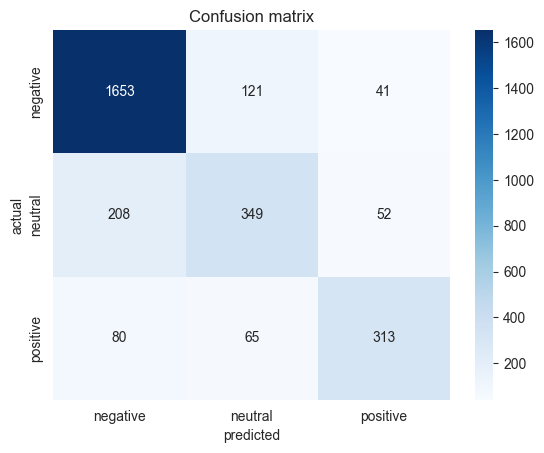

In [112]:
skf = StratifiedKFold(5, shuffle=True, random_state=42)
cv = cross_val_score(lr, X, y, cv=skf, scoring='accuracy')
print(cv.round(3))
print('cv accuracy:', round(cv.mean(),3), '+/-', round(cv.std(),3))
print('target > 80% met:', cv.mean() >= 0.80)
print('inside +/-5% of target:', abs(cv.mean()-0.80) <= 0.05)

labs = ['negative','neutral','positive']
cm = confusion_matrix(y_test, pred, labels=labs)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labs, yticklabels=labs)
plt.title('Confusion matrix')
plt.xlabel('predicted'); plt.ylabel('actual')
plt.savefig('outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Predict sentiment for every tweet. Predictions are made out of fold, so the model never predicts a tweet it trained on. Then look at the trend over time.

date
2015-02-17     945
2015-02-18    1406
2015-02-19    1286
2015-02-20    1504
2015-02-21    1411
2015-02-22    2380
2015-02-23    3493
2015-02-24    1982
dtype: int64


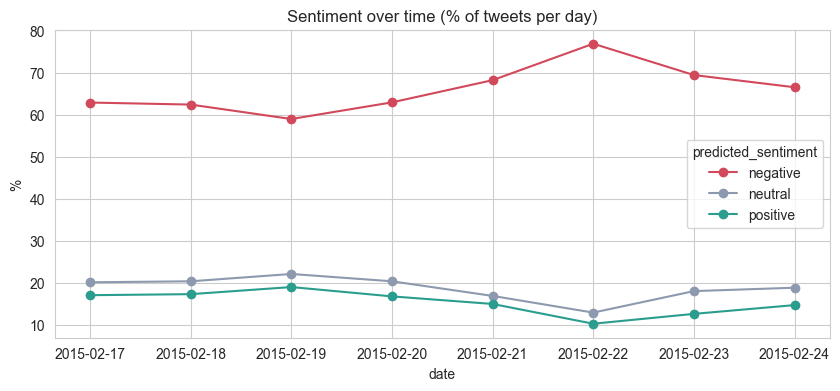

In [113]:
# predictions for every tweet (out of fold, so the model never sees its own tweet)
df['predicted_sentiment'] = cross_val_predict(lr, X, y, cv=skf)

daily = df.groupby(['date','predicted_sentiment']).size().unstack(fill_value=0)
daily_pct = daily.div(daily.sum(axis=1), axis=0)*100
print(daily.sum(axis=1))

daily_pct.plot(figsize=(10,4), marker='o', color={'negative':'#d1495b','neutral':'#8d99ae','positive':'#2a9d8f'})
plt.title('Sentiment over time (% of tweets per day)')
plt.ylabel('%')
plt.savefig('outputs/sentiment_time_series.png', dpi=150, bbox_inches='tight')
plt.show()

Sentiment by airline, and why people complain.

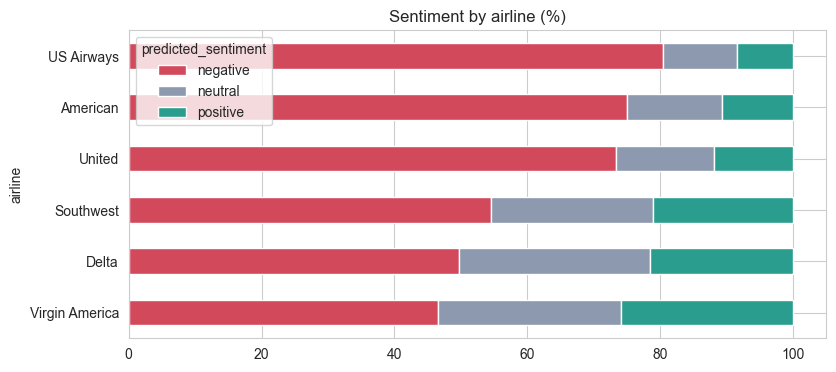

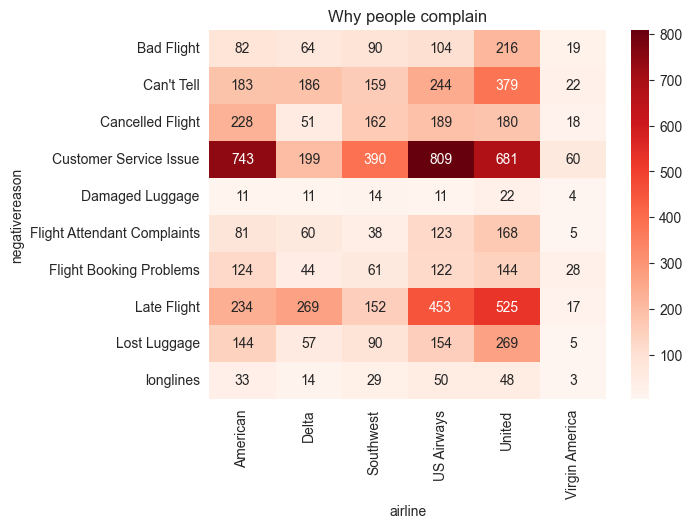

In [114]:
air = pd.crosstab(df['airline'], df['predicted_sentiment'], normalize='index')*100
air = air.sort_values('negative')
air[['negative','neutral','positive']].plot(kind='barh', stacked=True, figsize=(9,4), color=['#d1495b','#8d99ae','#2a9d8f'])
plt.title('Sentiment by airline (%)')
plt.savefig('outputs/sentiment_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()


reasons = pd.crosstab(df['negativereason'], df['airline'])
sns.heatmap(reasons, cmap='Reds', annot=True, fmt='d')
plt.title('Why people complain')
plt.savefig('outputs/complaint_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

Sentiment by user timezone, as a rough demographic.

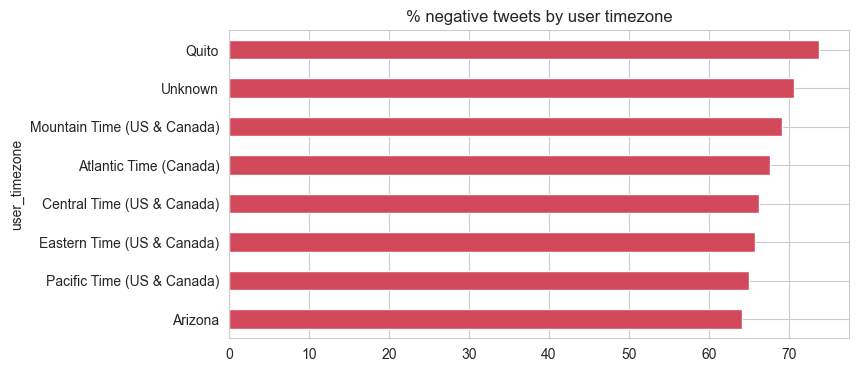

In [115]:
# timezone is the only user info we have, so use it as a rough demographic
top_tz = df['user_timezone'].value_counts().head(8).index
tz = df[df['user_timezone'].isin(top_tz)]
tz_neg = (tz['predicted_sentiment']=='negative').groupby(tz['user_timezone']).mean().sort_values()*100

tz_neg.plot(kind='barh', figsize=(8,4), color='#d1495b')
plt.title('% negative tweets by user timezone')
plt.savefig('outputs/sentiment_by_timezone.png', dpi=150, bbox_inches='tight')
plt.show()

Word clouds for positive and negative tweets.

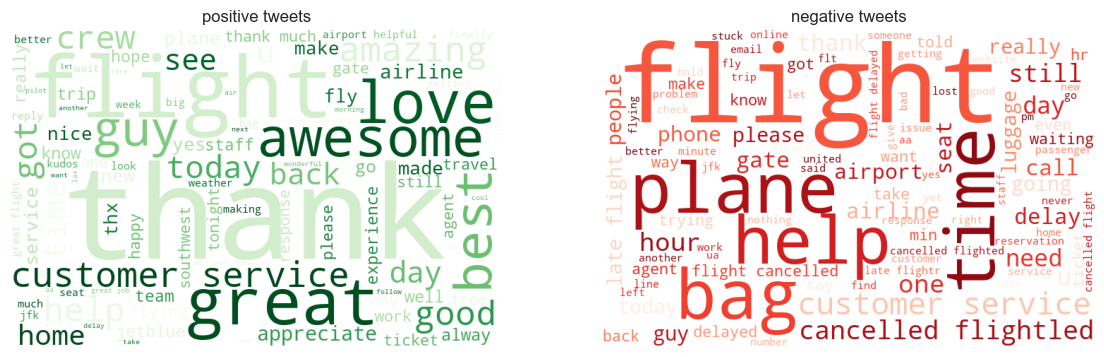

In [116]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
for a, s, col in zip(ax, ['positive','negative'], ['Greens','Reds']):
    txt = ' '.join(df.loc[df['predicted_sentiment']==s, 'clean_text'])
    wc = WordCloud(width=700, height=450, background_color='white', colormap=col, max_words=100).generate(txt)
    a.imshow(wc)
    a.set_title(s+' tweets')
    a.axis('off')

plt.savefig('outputs/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

Top words for each sentiment, from a small word-only model so the words are easy to read.

In [117]:
# small word only model, just so the top words are easy to read
vec = TfidfVectorizer(ngram_range=(1,2), min_df=3)
Xw = vec.fit_transform(df['clean_text'])
clf = LogisticRegression(max_iter=1000).fit(Xw, df['airline_sentiment'])
words = np.array(vec.get_feature_names_out())

top = {}
for i,c in enumerate(clf.classes_):
    top[c] = words[np.argsort(clf.coef_[i])[-10:][::-1]]

print(pd.DataFrame(top))

  negative             neutral    positive
0     hour                  hi      thanks
1      not            question       great
2       no              policy       thank
3    worst              chance     awesome
4       hr              avgeek        love
5  delayed  destinationdragons     amazing
6     hold     delay cancelled        best
7      bag            possible         thx
8  nothing                  dm  appreciate
9  luggage                 ceo   excellent


Brand insights: one table per airline, then save the results.

In [118]:
summary = df.groupby('airline').agg(
    tweets=('tweet_id','count'),
    pct_negative=('predicted_sentiment', lambda v:(v=='negative').mean()*100),
    pct_positive=('predicted_sentiment', lambda v:(v=='positive').mean()*100)).round(1)

summary['top_complaint'] = df[df['predicted_sentiment']=='negative'].groupby('airline')['negativereason'].agg(lambda v:v.value_counts().index[0])
print(summary.sort_values('pct_negative'))

df[['tweet_id','airline','text','clean_text','airline_sentiment','vader_label','predicted_sentiment','date']].to_csv('outputs/tweets_with_sentiment.csv', index=False)
print('saved')

                tweets  pct_negative  pct_positive           top_complaint
airline                                                                   
Virgin America     503          46.5          25.8  Customer Service Issue
Delta             2208          49.8          21.6             Late Flight
Southwest         2405          54.5          21.0  Customer Service Issue
United            3801          73.4          11.9  Customer Service Issue
American          2590          75.1          10.7  Customer Service Issue
US Airways        2900          80.4           8.4  Customer Service Issue
saved
